# Position-dependent photon fields / 2 - Propagating through a spatially-scaled photon field

Notebook 1 generated and verified the $1/r$-scaled `PowerlawPhotonField`. Here that field is put to
use: a power-law gamma-ray beam is propagated through the **homogeneous** and the **$1/r$-scaled**
field, and the surviving spectra are compared with a simple analytic reference. A final section
checks how the result converges as the spatial grid is refined.

### Geometry
One-dimensional. The source sits at $x=+5$ kpc and emits in the $-x$ direction; `Observer1D` detects
at $x=0$, so every photon crosses the column $[0,5]$ kpc. The runs are **absorption-only**:
`EMPairProduction` is added with `haveElectrons=False`, and an `ObserverElectronVeto` discards any
$e^\pm$, so a photon is simply removed when it pair-produces. The scaled field is less dense, absorbs
less, and so its cutoff lies at higher energy than the homogeneous one.

> **Step size matters.** `EMPairProduction` freezes the interaction rate at the start of each step,
> so for a spatially varying field the step must be small compared with $r_s=0.2$ kpc;
> `MAX_STEP = 0.01 kpc` is used throughout.

## Setup

Constants, the scaling profile, the per-node field writers, the `generate_spatial_field` helper and a
few analysis utilities. The on-disk conventions (filename coordinates, reversed energy/density
ordering) are explained in notebook 1; the writers are repeated here so this notebook is
self-contained. The base tables (`PowerlawPhotonField`) must already exist in the share folder — run
notebook 1 first.

In [1]:
from pathlib import Path

import crpropa as crp
import matplotlib.pyplot as plt
import numpy as np
from crpropa import GeV, MeV, Output, PeV, Vector3d, eV, kpc

# share folder this CRPropa build reads its tables from
CRPROPA_DATA = Path(crp.getDataPath(""))
BASE_FIELD = "PowerlawPhotonField"  # homogeneous base field (tables from notebook 1)
SPATIAL_FIELD = "PowerlawPhotonFieldTest1R"  # 1/r-scaled field (no "_" in the name)

# 1-D geometry, source and propagation
X_SRC = 5.0 * kpc  # source at +5 kpc, emits in -x, observer at x=0
E_SRC_MIN, E_SRC_MAX, SOURCE_INDEX = 10 * GeV, 10 * PeV, -1.0
E_MIN_STOP = 10 * MeV
MIN_STEP, MAX_STEP = 1e-4 * kpc, 1e-2 * kpc  # step must resolve r_s = 0.2 kpc

# analysis binning
N_EVENTS = 100_000
E_MIN_EV, E_MAX_EV, N_BINS = 1e10, 1e16, 60
bins = np.logspace(np.log10(E_MIN_EV), np.log10(E_MAX_EV), N_BINS + 1)
centers = np.sqrt(bins[:-1] * bins[1:])


def f_soft_1_over_r(x, y=0.0, z=0.0, A=1.0, r_s=0.2):
    """Softened central scaling f(0)=1, falling outward as r_s / (r + r_s)."""
    r = np.sqrt(x * x + y * y + z * z)
    return A * r_s / (r + r_s)

### Per-node field writers
`generate_spatial_field` writes one file per grid node, each scaled by $f$ (see notebook 1 for the
on-disk format). The fields are written into the share folder and kept there.

In [2]:
def node_suffix(x, y, z):
    # store -x: the reader reconstructs the coordinate from the filename
    return f"node_{-x:.8g}_{y:.8g}_{z:.8g}"


def _data_lines(path):
    return [l for l in open(path) if l.strip() and not l.lstrip().startswith("#")]


def _write_reversed(src, dst, scale=1.0):
    """Energy/density: reverse line order; optionally scale every column."""
    with open(dst, "w") as f:
        for line in reversed(_data_lines(src)):
            f.write(" ".join(f"{float(v) * scale:.16e}" for v in line.split()) + "\n")


def _scale_rate_like(src, dst, scale):
    """Rate/CDF: keep order and header; scale all columns except the first."""
    seen = False
    with open(src) as fin, open(dst, "w") as fout:
        for line in fin:
            s = line.strip()
            if not s or s.startswith("#"):
                fout.write(line)
                continue
            p = s.split()
            if not seen and len(p) > 2:  # CDF s-grid row: keep unchanged
                fout.write(line)
                seen = True
                continue
            seen = True
            fout.write(
                p[0] + " " + " ".join(f"{float(v) * scale:.16e}" for v in p[1:]) + "\n"
            )


def generate_spatial_field(name, n_nodes=21):
    """Write the 1/r-scaled field with n_nodes nodes over x in [-5, 5] kpc."""
    assert "_" not in name
    be = CRPROPA_DATA / "Scaling" / f"{BASE_FIELD}_photonEnergy.txt"
    bd = CRPROPA_DATA / "Scaling" / f"{BASE_FIELD}_photonDensity.txt"
    br = CRPROPA_DATA / "EMPairProduction" / f"rate_{BASE_FIELD}.txt"
    bc = CRPROPA_DATA / "EMPairProduction" / f"cdf_{BASE_FIELD}.txt"
    oe = CRPROPA_DATA / "Scaling" / name / "photonEnergy"
    od = CRPROPA_DATA / "Scaling" / name / "photonDensity"
    orr = CRPROPA_DATA / "EMPairProduction" / name / "Rate"
    oc = CRPROPA_DATA / "EMPairProduction" / name / "CumulativeRate"
    for d in (oe, od, orr, oc):
        d.mkdir(parents=True, exist_ok=True)
    for x in np.linspace(-5, 5, n_nodes):
        f = f_soft_1_over_r(x)
        suf = node_suffix(x, 0.0, 0.0)
        _write_reversed(be, oe / f"{name}_{suf}.txt")
        _write_reversed(bd, od / f"{name}_{suf}.txt", scale=f)
        _scale_rate_like(br, orr / f"rate_{name}_{suf}.txt", f)
        _scale_rate_like(bc, oc / f"cdf_{name}_{suf}.txt", f)


generate_spatial_field(SPATIAL_FIELD)
print("generated", SPATIAL_FIELD)

generated PowerlawPhotonFieldTest1R


### Analysis helpers
`binned_spectrum` reads a CRPropa `Event1D` output and histograms it into counts per $\Delta\log_{10}E$;
`base_rate` interpolates the homogeneous pair-production rate.

In [3]:
def binned_spectrum(path):
    """Surviving counts per dlog10E from a CRPropa Event1D output file."""
    d = np.genfromtxt(path, names=True)
    counts, _ = np.histogram(d["E"], bins=bins, weights=d["W"])
    return counts / np.diff(np.log10(bins))


def base_rate(E_eV):
    """Homogeneous pair-production rate [1/Mpc] interpolated at E_eV."""
    t = np.genfromtxt(
        CRPROPA_DATA / "EMPairProduction" / f"rate_{BASE_FIELD}.txt", comments="#"
    )
    return np.interp(np.log10(E_eV), t[:, 0], t[:, 1], left=0.0, right=0.0)

## 1. Surviving spectrum: homogeneous vs $1/r$-scaled

`run_spectrum` propagates the power-law beam through a given field and saves the survivors. It is
called once for the homogeneous `TabularPhotonField` (written to `events_homogeneous.txt`) and once
for the `TabularSpatialPhotonField` (`events_1r.txt`); both files are kept for inspection or re-use.

In [4]:
def run_spectrum(field, output_file, n=N_EVENTS):
    """Propagate the power-law beam through `field`, saving the survivors to `output_file`."""
    sim = crp.ModuleList()
    sim.add(crp.SimplePropagation(MIN_STEP, MAX_STEP))  # bounded step (resolves r_s)
    sim.add(crp.EMPairProduction(field, False, 0.0))  # absorption only, no e+- produced
    sim.add(crp.MinimumEnergy(E_MIN_STOP))
    sim.add(crp.MaximumTrajectoryLength(20 * kpc))

    obs = crp.Observer()
    obs.add(crp.Observer1D())
    obs.add(crp.ObserverElectronVeto())  # we are only interested in photons
    output = crp.TextOutput(output_file, Output.Event1D)
    output.setEnergyScale(eV)
    output.enable(output.WeightColumn)
    output.disable(output.CandidateTagColumn)  # not needed in this analysis
    obs.onDetection(output)
    sim.add(obs)

    source = crp.Source()
    source.add(crp.SourcePosition(Vector3d(X_SRC, 0, 0)))
    source.add(crp.SourceDirection(Vector3d(-1, 0, 0)))
    source.add(crp.SourceParticleType(22))
    source.add(crp.SourcePowerLawSpectrum(E_SRC_MIN, E_SRC_MAX, SOURCE_INDEX))
    sim.run(source, n, True)
    output.close()


run_spectrum(crp.TabularPhotonField(BASE_FIELD, False), "events_homogeneous.txt")
run_spectrum(crp.TabularSpatialPhotonField(SPATIAL_FIELD), "events_1r.txt")
print("done")

crpropa::ModuleList: Number of Threads: 8


crpropa::ModuleList: Number of Threads: 8


done


Bin both runs and build the analytic reference. The column traversed shrinks from $L_0=5$ kpc
(homogeneous) to $L_s=\int_0^5 f\,\mathrm{d}x$ (scaled); the flat injection normalisation is
$\mathrm{norm}=N/\log_{10}(E_{\max}/E_{\min})$.

In [5]:
spec_unscaled = binned_spectrum("events_homogeneous.txt")
spec_scaled = binned_spectrum("events_1r.txt")

x = np.linspace(0, 5, 5000)
L0 = 5.0 / 1000.0  # homogeneous column [Mpc]
Ls = np.trapezoid(f_soft_1_over_r(x), x) / 1000.0  # 1/r-scaled column [Mpc]
norm = N_EVENTS / np.log10(E_MAX_EV / E_MIN_EV)  # flat counts / dlog10E for index -1
rate_c = base_rate(centers)
spec_ref_unscaled = norm * np.exp(-rate_c * L0)
spec_ref_scaled = norm * np.exp(-rate_c * Ls)
print(f"mean scaling <f> = Ls / L0 = {Ls / L0:.3f}")

mean scaling <f> = Ls / L0 = 0.130


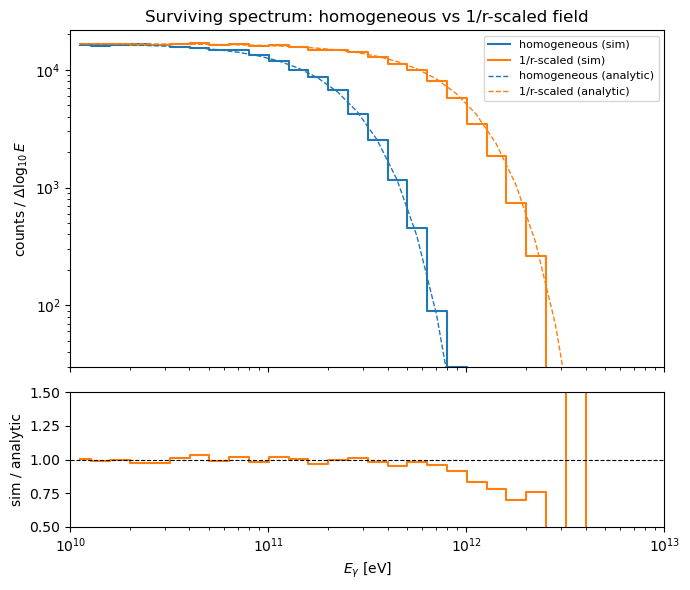

In [6]:
fig, (ax, axr) = plt.subplots(
    2, 1, figsize=(7, 6), sharex=True, gridspec_kw={"height_ratios": [2.5, 1]}
)
ax.step(centers, spec_unscaled, where="mid", color="C0", label="homogeneous (sim)")
ax.step(centers, spec_scaled, where="mid", color="C1", label="1/r-scaled (sim)")
ax.plot(centers, spec_ref_unscaled, "C0--", lw=1, label="homogeneous (analytic)")
ax.plot(centers, spec_ref_scaled, "C1--", lw=1, label="1/r-scaled (analytic)")
ax.set_yscale("log")
ax.set_ylim(3e1, 1.3 * norm)
ax.set_ylabel(r"counts / $\Delta\log_{10}E$")
ax.set_title("Surviving spectrum: homogeneous vs 1/r-scaled field")
ax.legend(fontsize=8)

with np.errstate(divide="ignore", invalid="ignore"):
    axr.step(
        centers,
        np.where(spec_ref_scaled > 0, spec_scaled / spec_ref_scaled, np.nan),
        where="mid",
        color="C1",
    )
axr.axhline(1, color="k", ls="--", lw=0.8)
axr.set_xscale("log")
axr.set_xlim(1e10, 1e13)  # survivors cut off well below the 10 PeV injection ceiling
axr.set_ylim(0.5, 1.5)
axr.set_ylabel("sim / analytic")
axr.set_xlabel(r"$E_\gamma$ [eV]")
plt.tight_layout()
plt.show()

The scaled field absorbs less, so its cutoff sits about a decade higher than the homogeneous one, and
the simulation tracks the analytic reference across the turnover. The tail is noisy at this
`N_EVENTS`; raise it for a publication-quality figure.

## 2. Convergence with grid sampling

The spatial rate is taken from the **nearest node**, so a coarse grid mis-resolves the steep central
region. The same beam is propagated through the $1/r$ field generated at several samplings and
compared with the continuous-field reference from section 1. Each grid and its event file
(`events_grid<N>.txt`) are kept on disk.

In [7]:
GRID_SIZES = [11, 21, 41]

specs = {}
for n_nodes in GRID_SIZES:
    name = f"PowerlawGrid{n_nodes}"
    generate_spatial_field(name, n_nodes)
    run_spectrum(crp.TabularSpatialPhotonField(name), f"events_grid{n_nodes}.txt")
    specs[n_nodes] = binned_spectrum(f"events_grid{n_nodes}.txt")
print("done")

crpropa::ModuleList: Number of Threads: 8


crpropa::ModuleList: Number of Threads: 8


crpropa::ModuleList: Number of Threads: 8


done


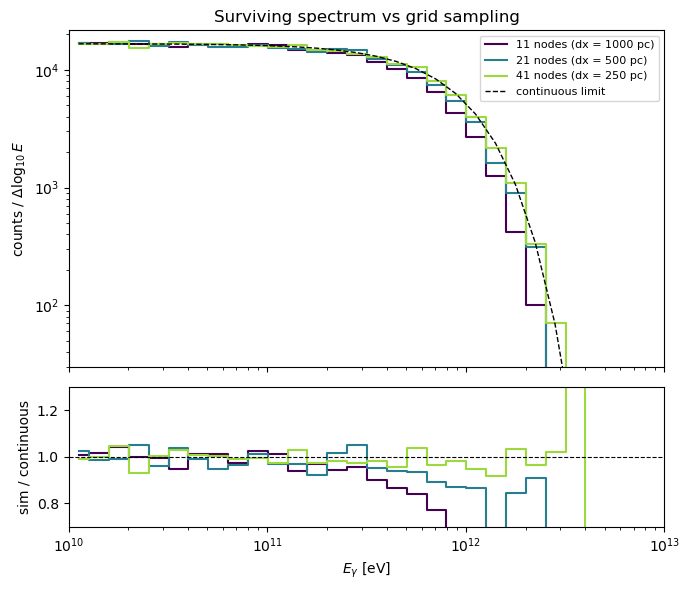

In [8]:
fig, (ax, axr) = plt.subplots(
    2, 1, figsize=(7, 6), sharex=True, gridspec_kw={"height_ratios": [2.4, 1]}
)
colors = plt.cm.viridis(np.linspace(0, 0.85, len(GRID_SIZES)))
for color, n_nodes in zip(colors, GRID_SIZES):
    dx = 10000 / (n_nodes - 1)  # node spacing [pc]
    ax.step(
        centers,
        specs[n_nodes],
        where="mid",
        color=color,
        label=f"{n_nodes} nodes (dx = {dx:.0f} pc)",
    )
    with np.errstate(divide="ignore", invalid="ignore"):
        axr.step(
            centers,
            np.where(spec_ref_scaled > 0, specs[n_nodes] / spec_ref_scaled, np.nan),
            where="mid",
            color=color,
        )
ax.plot(centers, spec_ref_scaled, "k--", lw=1, label="continuous limit")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim(3e1, 1.3 * norm)
ax.set_ylabel(r"counts / $\Delta\log_{10}E$")
ax.set_title("Surviving spectrum vs grid sampling")
ax.legend(fontsize=8)

axr.axhline(1, color="k", ls="--", lw=0.8)
axr.set_xscale("log")
axr.set_xlim(1e10, 1e13)  # survivors cut off well below the 10 PeV injection ceiling
axr.set_ylim(0.7, 1.3)
axr.set_ylabel("sim / continuous")
axr.set_xlabel(r"$E_\gamma$ [eV]")
plt.tight_layout()
plt.show()

## 3. Notes

- The samplings overlap and track the continuous limit through the turnover; the coarsest grid
  deviates most near the cutoff. For this smooth $1/r$ profile even 11 nodes is only modestly off — a
  sharper profile, or a grid that misses the central peak, would widen the spread.
- The propagation step must stay well below $r_s$ (here `MAX_STEP = 0.01` kpc), since
  `EMPairProduction` freezes the rate over each step.